In [1]:
import sys
sys.path.append("../..")
import torch
from torch.distributions import Normal
from sbi.inference import NPE_A
from sbi.analysis import pairplot
import numpy as np
import matplotlib.pyplot as plt
import scipy

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


We hypothesize that SNPE-A will struggle to provide a good posterior approximation when the prior (or proposal) mass is far from the posterior mass. 

We can test this in 1D by considering the following example:

$$p(\theta) = N(\theta ; 0, 1)$$

$$p(x|\theta) = N(x; \theta , 1)$$

where we observe $x_\text{obs}\in \{0,1,2,3,...\}$ ($x_\text{obs}$ is $x_\text{obs}$ standard deviations above the mean of the prior). In this case, we have a posterior given analytically by

$$p(\theta|x_\text{obs}) = N\left(\theta; \frac{x_\text{obs}}{2}, \frac{1}{2}\right)$$

We expect that, for large enough $x$ (think over $\approx 4\sigma$ away from prior mean), the SNPE-A algorithm will struggle to approximate the true posterior, since it will be extrapolating past the $(x, \theta)$ training pairs. 

Note that the SNPE-A algorithm (and therefore the python implementation from `sbi`) only allows Gaussian or uniform priors.

In [2]:
from utils_1d_examples.gaussiangaussian_far import prior_pdf, likelihood_pdf, posterior_pdf, plot_approximate_posterior

# Amortized Inference with (S)NPE-A

In [3]:
# Define simulator
def model(mu):
    return mu + torch.randn_like(mu)

# Define prior
prior = torch.distributions.MultivariateNormal(torch.tensor([0.]), torch.tensor([[1.]]))


In [4]:
inference = NPE_A(prior=prior)  # (S)NPE-A algorithm (fast epsilon-free inference)
num_simulations = 2000  # number of (theta, x) pairs sampled and trained on
mu = prior.sample((num_simulations,))  # simulate parameters from prior
x = model(mu)  # simulate data for each parameter
inference = inference.append_simulations(mu, x)
density_estimator = inference.train()
posterior = inference.build_posterior()

def approximate_posterior(theta, x):
    """
    Output SNPE-A analytical posterior approximation \hat{p}(theta | x)

    theta and x must be 1D torch tensors
    """
    return torch.exp(posterior.potential(theta, x))

/Users/Lieve/Documents/Masters Project/sbi_venv/lib/python3.9/site-packages/torch/nn/init.py:582: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


 Neural network successfully converged after 31 epochs.

In [5]:
# Can plot histogram of samples OR analytical posterior approximation
# samples = posterior.sample((10000,), x=x_observed)

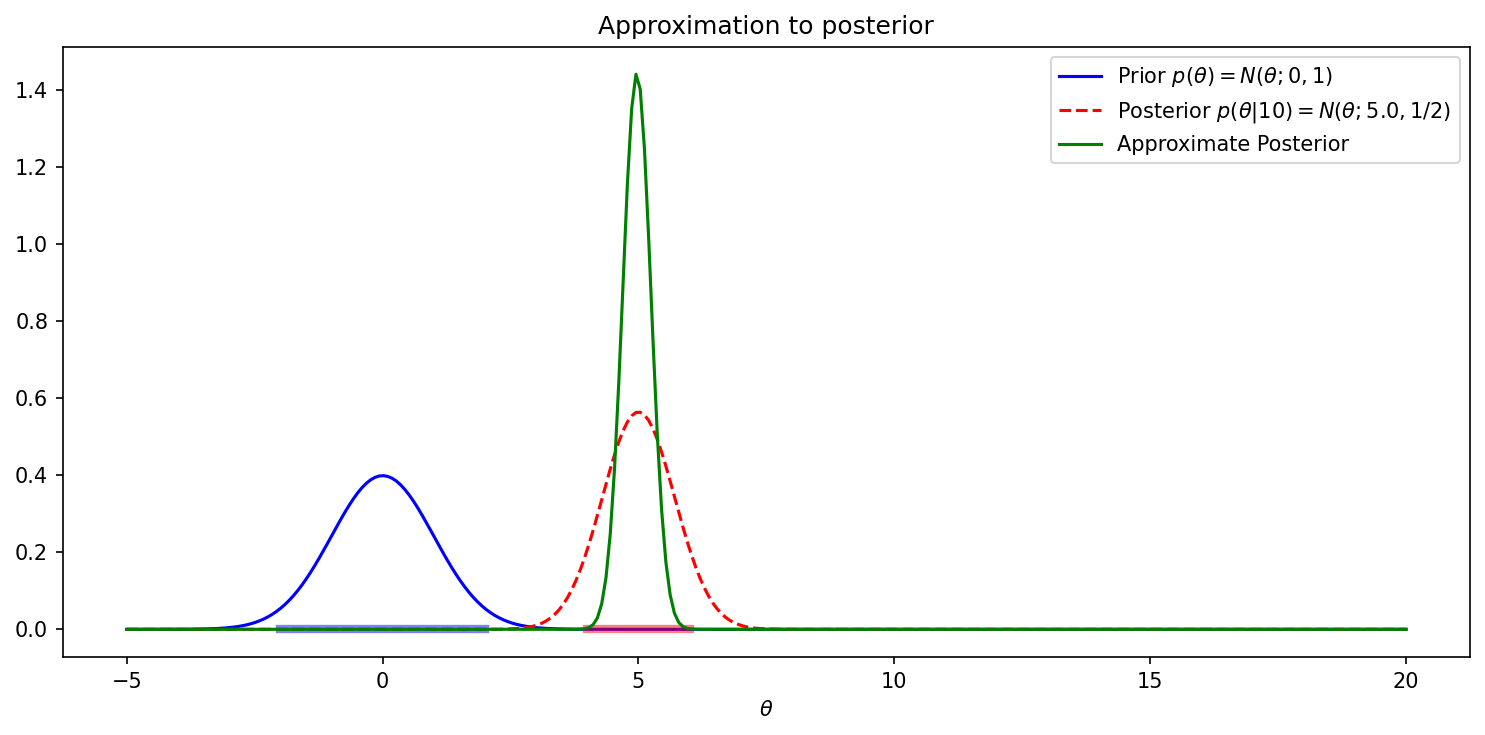

In [ ]:
x_observed = 10 # Observed data
theta_range = torch.linspace(-5,20,300).view(-1,1)
plot_approximate_posterior(approximate_posterior, prior_pdf, posterior_pdf, theta_range, x_observed)

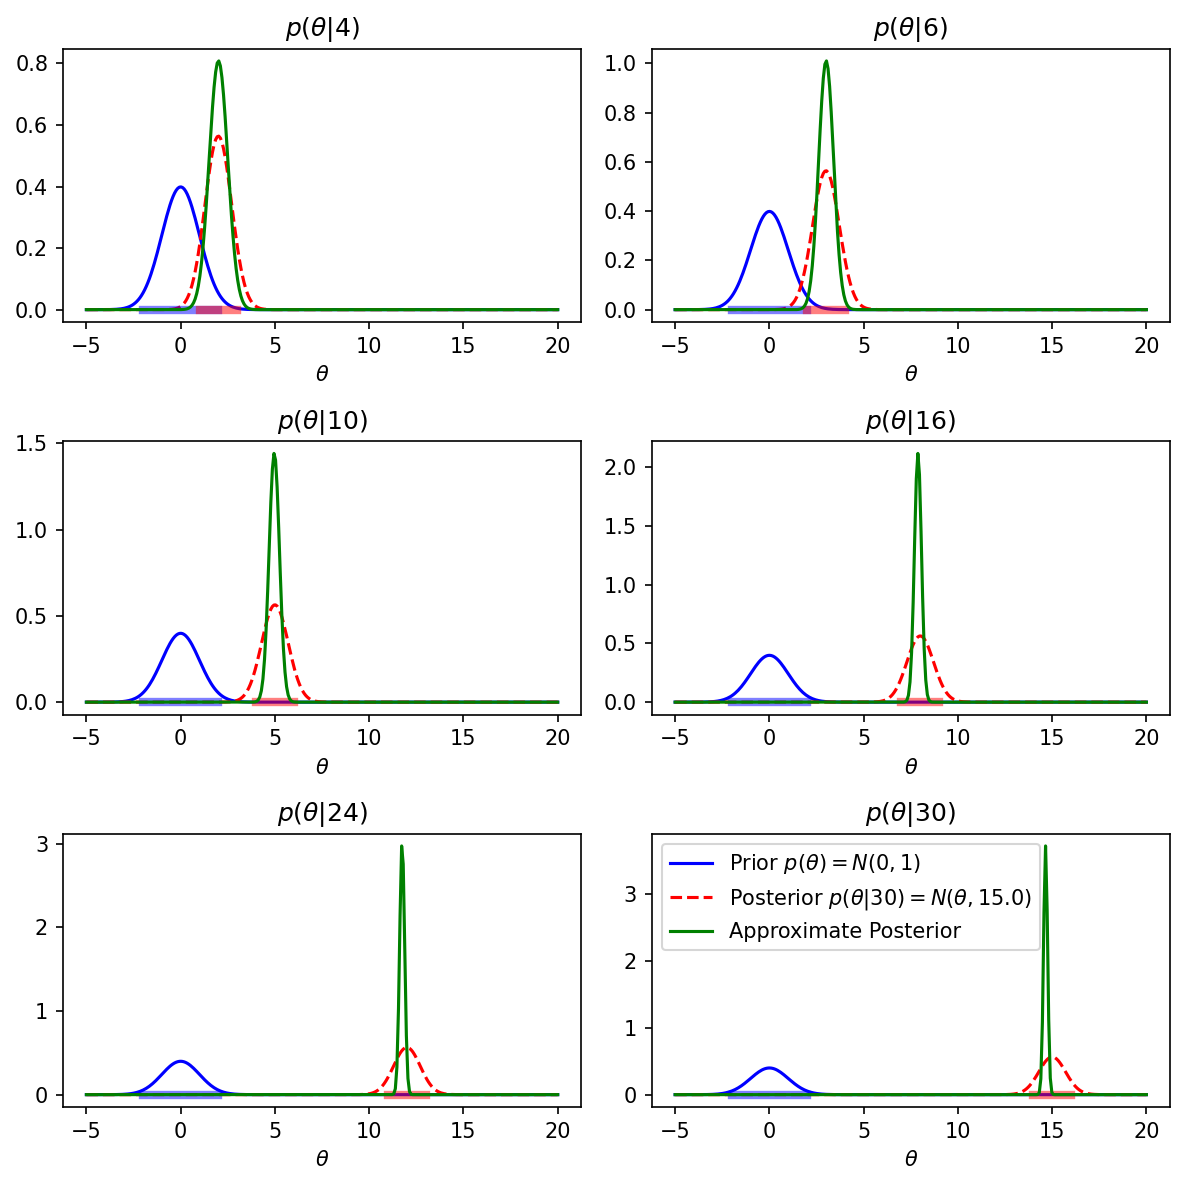

In [8]:
x_observed_values = [4,6,10,16,24,30]
theta_range = torch.linspace(-5,20,300).view(-1,1)
plot_approximate_posterior(approximate_posterior, prior_pdf, posterior_pdf, theta_range, x_observed_values)

AssertionError: The trailing dimensions of `theta_or_x` do not match the `event_shape`.

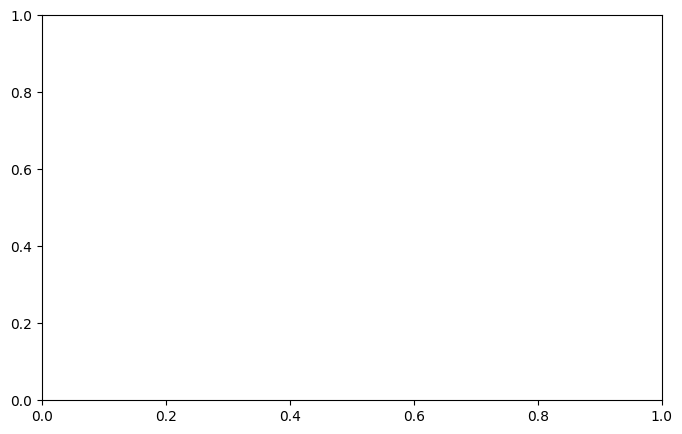

In [12]:
x_grid = torch.linspace(0,10,100).unsqueeze(0)
plot_posterior_summary(approximate_posterior, x_grid, n_samples=1000, ax=None)

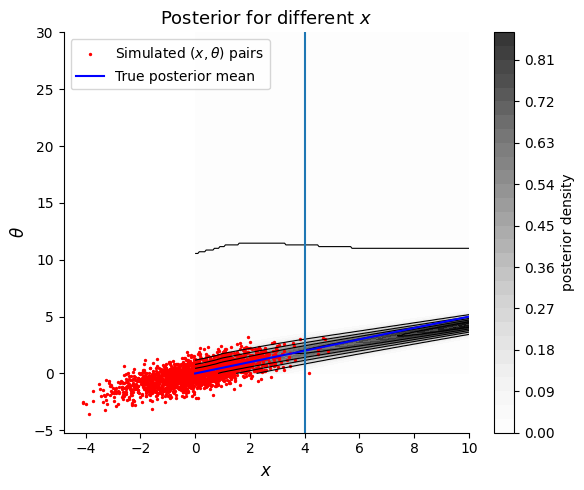

In [175]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Define ranges
theta_range = np.linspace(0, 30, 200)
x_range = np.linspace(0, 10, 200)
X, Y = np.meshgrid(x_range, theta_range)

# Flatten grid for batch evaluation
x_flat = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
theta_flat = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)

# Evaluate posterior potential in batches (avoid GPU/CPU overflow)
with torch.no_grad():
    log_posterior = posterior.potential(theta_flat, x_flat)

# Compute posterior density
Z = torch.exp(log_posterior).reshape(X.shape).detach().cpu().numpy()

# --- Simple contour plot (white background) ---
plt.style.use("default")
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Filled contours (light grayscale)
contour = ax.contourf(X, Y, Z, levels=30, cmap="Greys", alpha=0.8)

# Clean contour lines
ax.contour(X, Y, Z, levels=5, colors="black", linewidths=0.8)

# Labels and title
ax.set_xlabel(r"$x$", fontsize=12)
ax.set_ylabel(r"$\theta$", fontsize=12)
ax.set_title(r"Posterior for different $x$", fontsize=13)

# Remove colorbar for minimalism (add if you prefer)
fig.colorbar(contour, ax=ax, label="posterior density")

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.scatter(x, mu, s=2, color="red", label=r"Simulated $(x, \theta)$ pairs")

ax.plot(x_range, x_range/2, color="blue", label="True posterior mean")

ax.axvline(4)

plt.tight_layout()
plt.legend()
plt.show()


### SBC on amortized (S)NPE-A

In [166]:
def npe_sbc(model, prior, posterior, num_sbi_runs=100, num_samples=100):
    ranks = []
    for i in range(num_sbi_runs):
        prior_sample = prior.sample() # Sample from prior. Returns tensor(number)
        simulated_datapoint = model(prior_sample) # Simulate a datapoint from the model given the prior sample. Returns tensor([[number]])
        posterior_samples = posterior.sample((num_samples,), x=simulated_datapoint, show_progress_bars=False) # Numpy array of (num_samples, ) samples.
        rank = torch.sum(prior_sample.item() * torch.ones_like(posterior_samples) > posterior_samples) # Rank statistic
        ranks.append(float(rank))
    plt.hist(np.array(ranks)/num_samples, label="SBC rank histogram")
    plt.xlim(0, 1)
    plt.xlabel("Rank")
    plt.legend()
    plt.show()
    return ranks

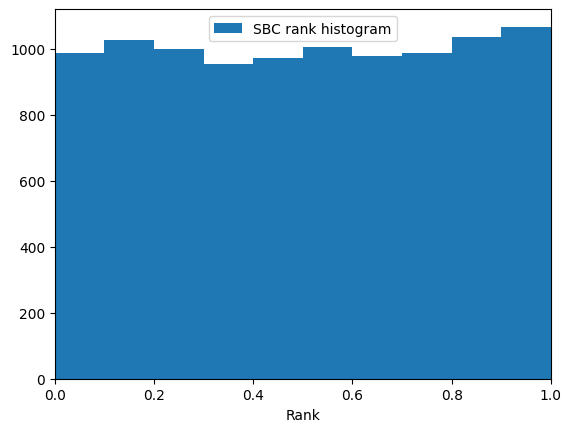

In [168]:
npe_sbc(model, prior, posterior, num_sbi_runs=10000, num_samples=1000)
pass

# Sequential inference with SNPE-A

https://sbi.readthedocs.io/en/latest/how_to_guide/02_multiround_inference.html